<a href="https://colab.research.google.com/github/vishnuwadkar/Machine-Learning/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [12]:
cols = ['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','FAlpha','fDist','class']
df = pd.read_csv("magic04.data", names = cols)

In [13]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,FAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [14]:
df["class"].unique()

array(['g', 'h'], dtype=object)

#### One Hot Encoding

In [15]:
df["class"] = (df["class"] == 'g').astype(int)

In [16]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,FAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


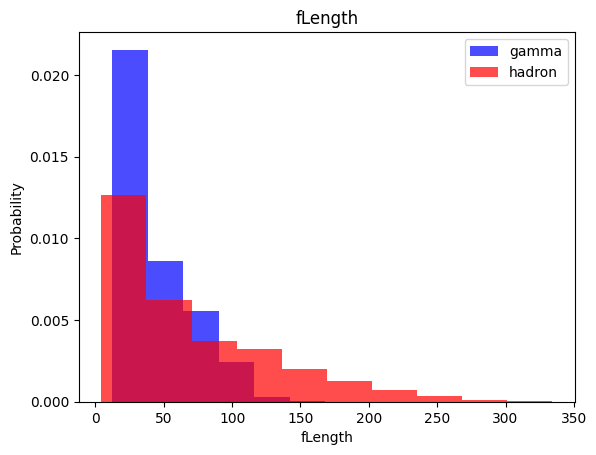

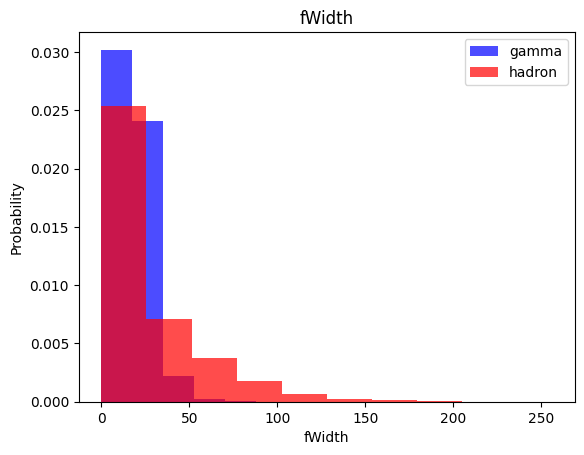

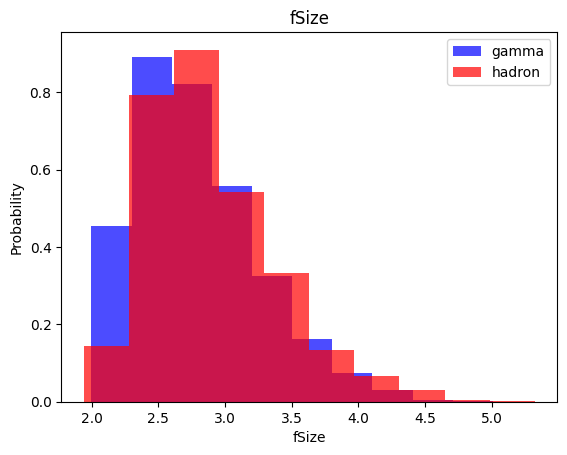

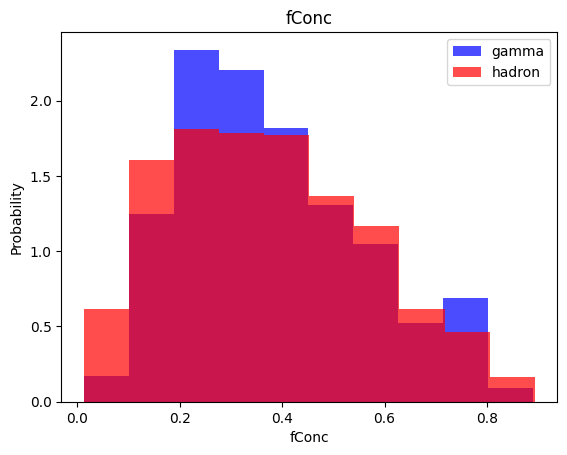

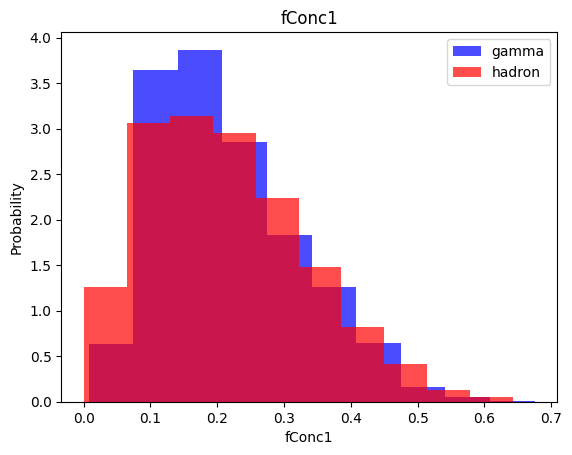

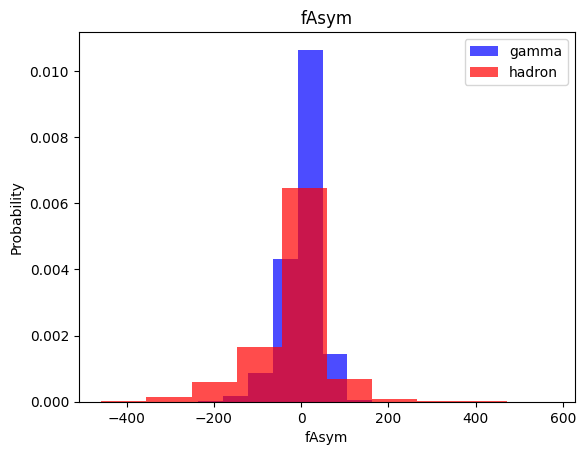

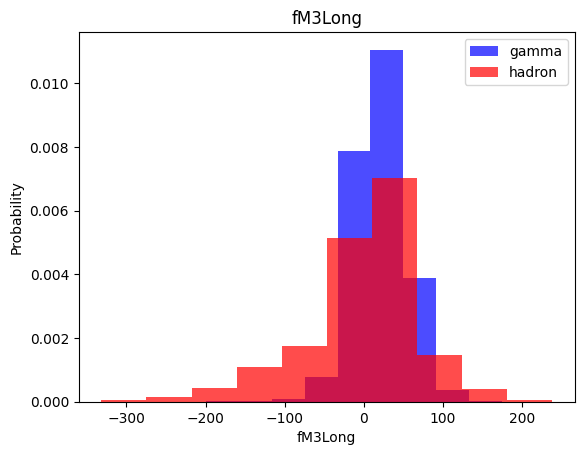

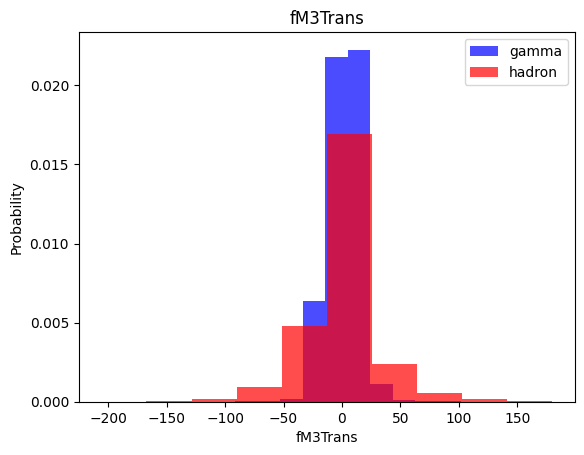

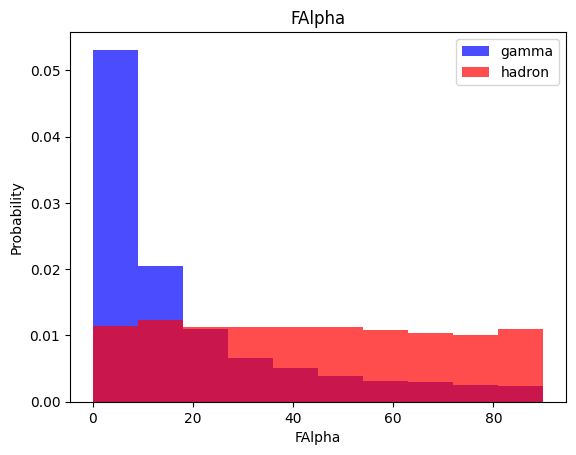

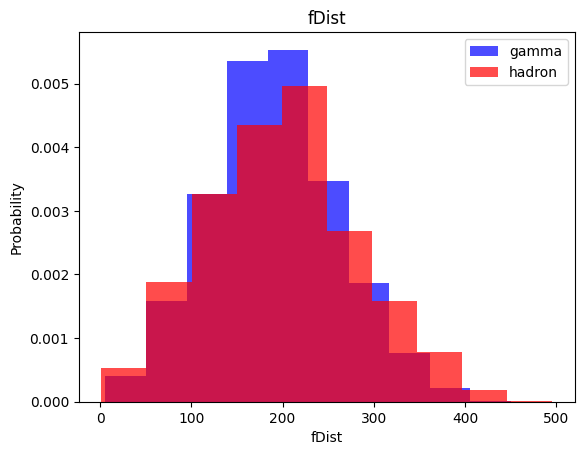

In [17]:
import matplotlib.pyplot as plt
for label in cols[:-1]:
  plt.hist(df[df['class']==1][label], color = 'blue', label = 'gamma', alpha = 0.7, density = True)
  plt.hist(df[df['class']==0][label], color = 'red', label = 'hadron', alpha = 0.7, density = True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()


### Training, Validation, Testing data

In [18]:
train, test, validation = np.split(df.sample(frac = 1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### Scaling the data

In [19]:
def scale_dataset(dataframe, oversample = False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values
  scaler = StandardScaler()
  x = scaler.fit_transform(x)   #scaling old x values and updating the x as new

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)
  #horizontally stacking x and y
  data = np.hstack((x, np.reshape(y,(-1,1))))
  return data, x, y

In [20]:
train_df = pd.DataFrame(train, columns=cols)
train, x_train, y_train = scale_dataset(train_df, oversample = True)
validation, x_valid, y_valid = scale_dataset(train_df, oversample = False)
test, x_test, y_test = scale_dataset(train_df, oversample = False)

In [21]:
print(len(y_train))
print(sum(y_train == 1))
print(sum(y_train == 0))


14750
7375
7375


#### We need to oversample the hadron data

## NEURAL NETWORK


In [22]:
import tensorflow as tf

In [23]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epoch):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation = 'relu', input_shape = (10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation = 'relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation = 'relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation = 'sigmoid'),
  ])
  nn_model.compile(optimizer = tf.keras.optimizers.Adam(lr), loss = 'binary_crossentropy', metrics = ['accuracy'])

  history = nn_model.fit(x_train, y_train, epochs = epoch, batch_size = batch_size, validation_split = 0.2, verbose= 0)

  return nn_model, history

In [24]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (8, 2))
  ax1.plot(history.history['loss'],label = 'loss')
  ax1.plot(history.history['val_loss'],label = 'val_loss')
  ax1.set_xlabel('epoch')
  ax1.set_ylabel('Binary Cross Entropy')
  ax2.plot(history.history['accuracy'],label = 'accuracy')
  ax2.plot(history.history['val_accuracy'],label = 'val_accuracy')
  ax2.set_xlabel('epoch')
  ax2.set_ylabel('accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

In [25]:
# plot_history(history)

NameError: name 'history' is not defined

In [ ]:
# history = nn_model.fit(x_train, y_train, epochs = 100, batch_size = 32, validation_split = 0.2 )

num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


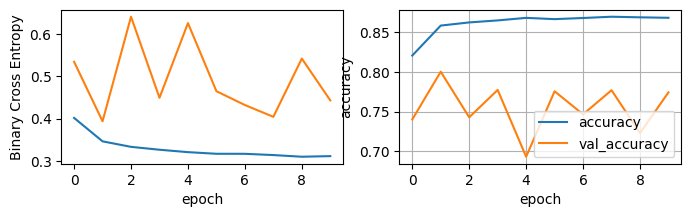

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8773 - loss: 0.2942
num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 64


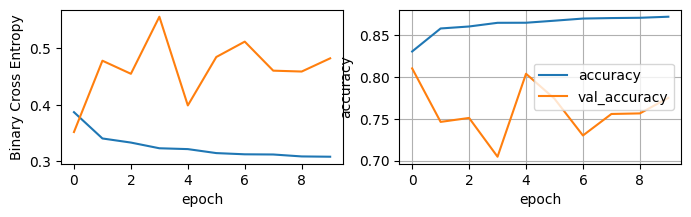

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8758 - loss: 0.2971
num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 128


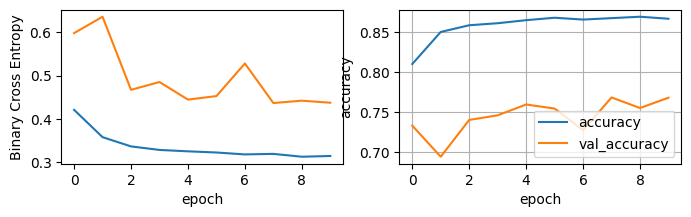

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8776 - loss: 0.2952
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 32


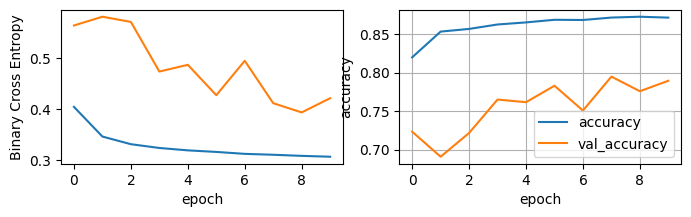

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8813 - loss: 0.2899
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 64


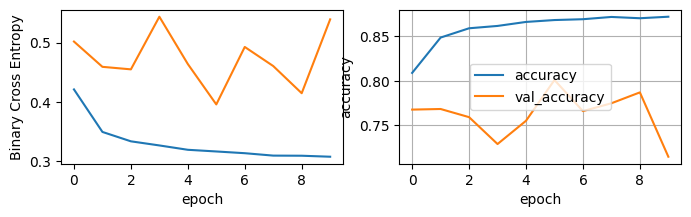

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.2952
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 128


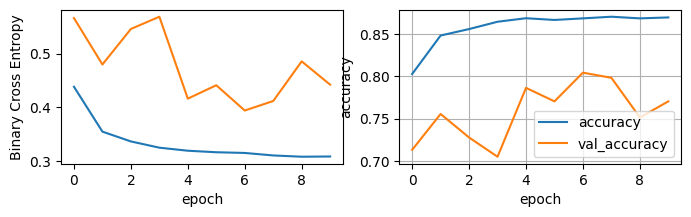

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8800 - loss: 0.2922
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 32


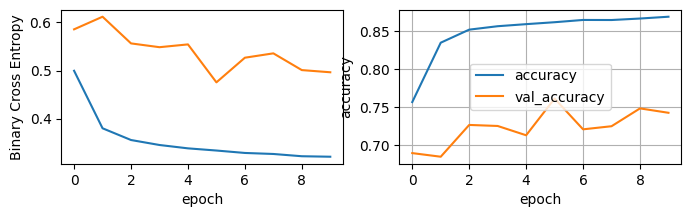

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8736 - loss: 0.3103
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 64


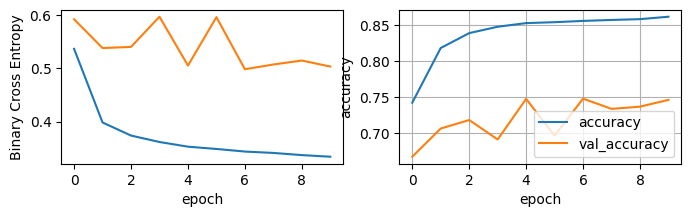

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8657 - loss: 0.3234
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 128


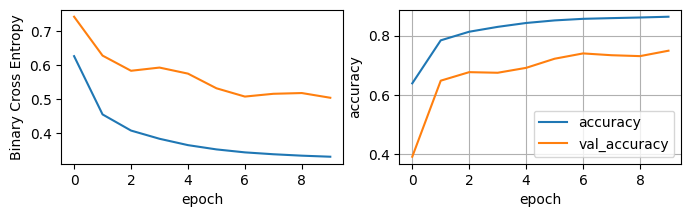

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8682 - loss: 0.3218
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 32


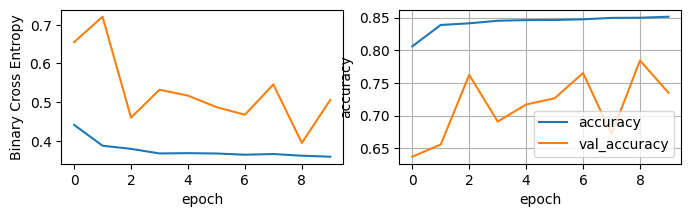

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 0.3155
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 64


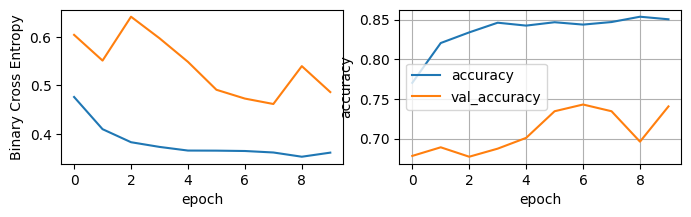

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8675 - loss: 0.3135
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 128


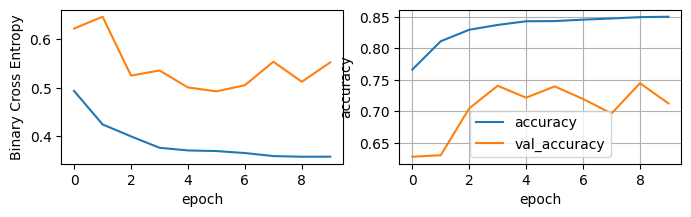

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8742 - loss: 0.3132
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 32


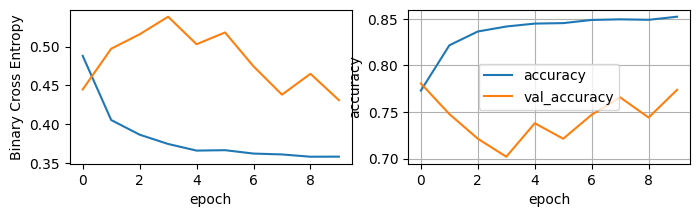

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8699 - loss: 0.3177
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 64


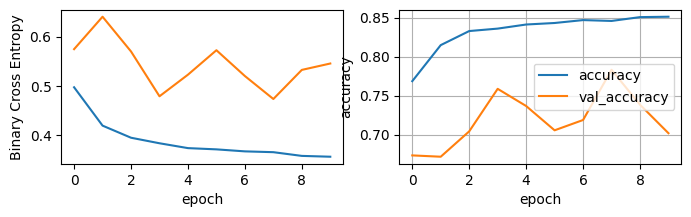

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8697 - loss: 0.3186
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 128


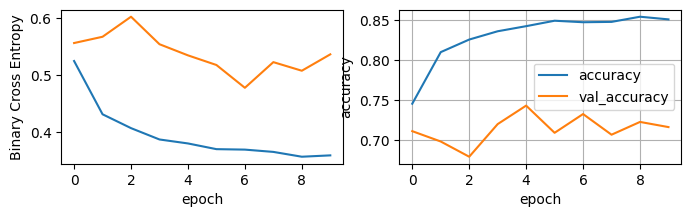

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8700 - loss: 0.3153
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 32


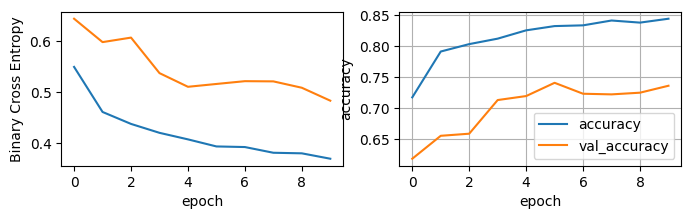

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3318
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 64


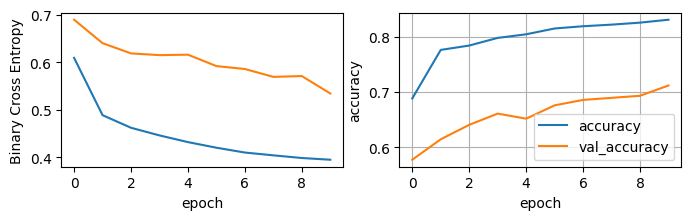

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8557 - loss: 0.3462
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 128


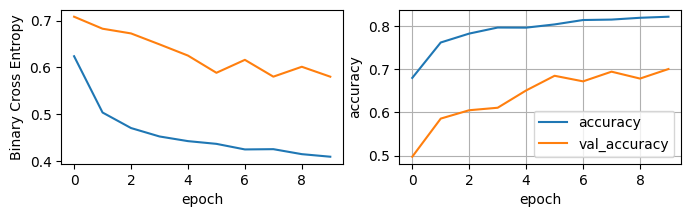

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8503 - loss: 0.3596
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 32


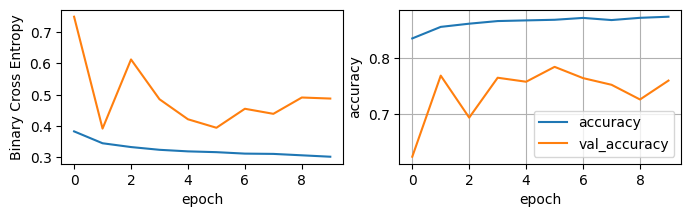

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8807 - loss: 0.2855
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 64


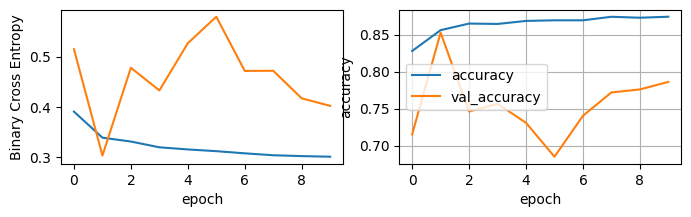

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8811 - loss: 0.2884
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 128


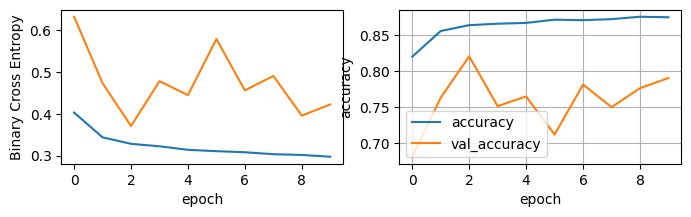

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8829 - loss: 0.2826
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 32


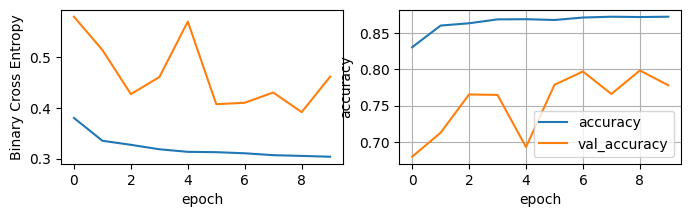

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8821 - loss: 0.2842
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 64


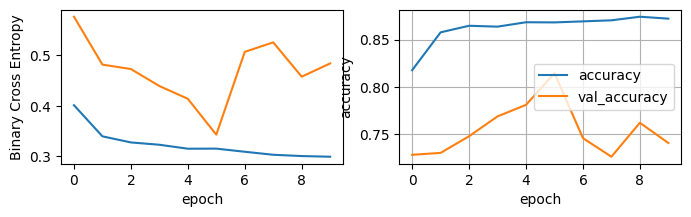

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8822 - loss: 0.2844
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 128


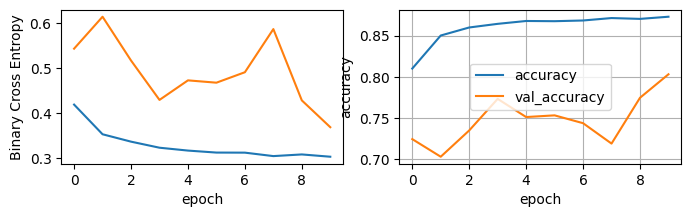

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8745 - loss: 0.2974
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 32


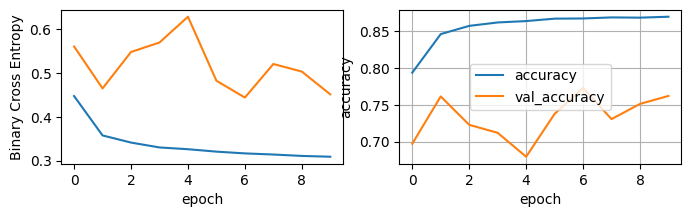

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8774 - loss: 0.2968
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 64


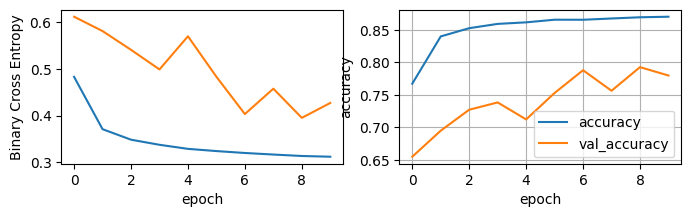

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8718 - loss: 0.3071
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 128


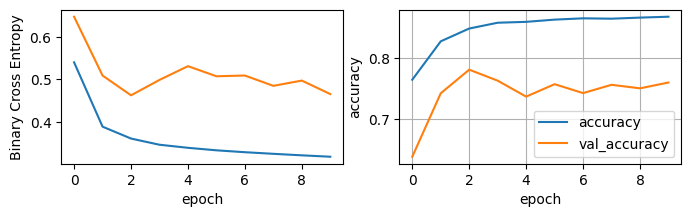

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8740 - loss: 0.3064
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 32


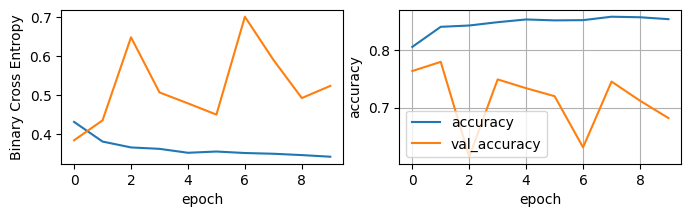

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8665 - loss: 0.3143
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 64


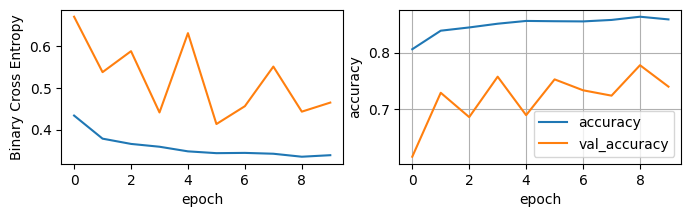

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8740 - loss: 0.3070
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 128


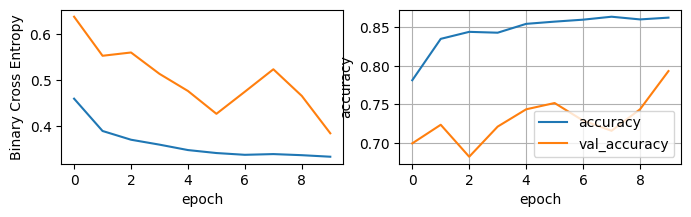

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.3069
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 32


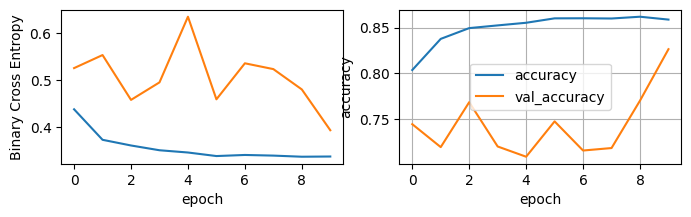

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8611 - loss: 0.3113
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 64


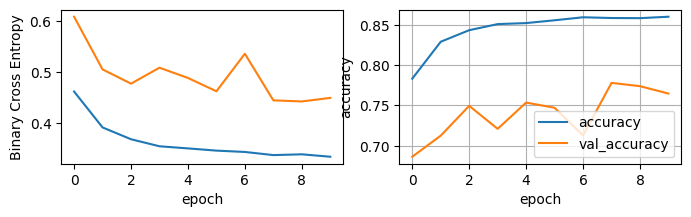

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.2987
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 128


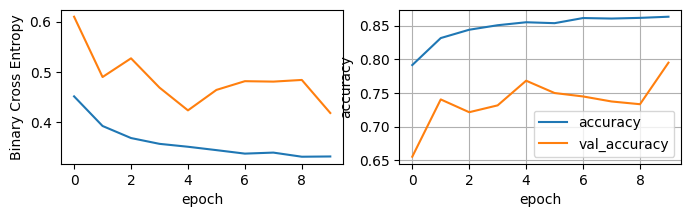

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8713 - loss: 0.3059
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 32


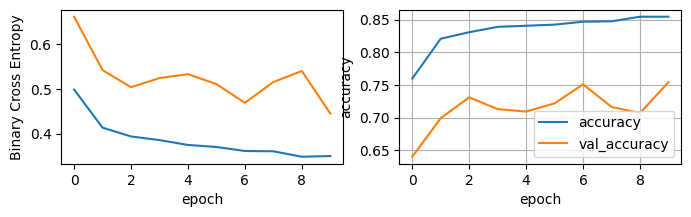

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8712 - loss: 0.3158
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 64


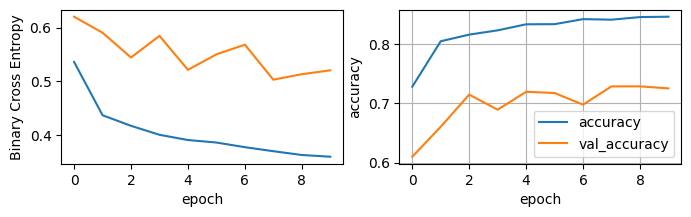

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8710 - loss: 0.3171
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 128


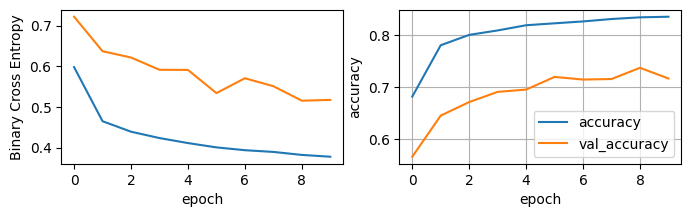

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.3350
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 32


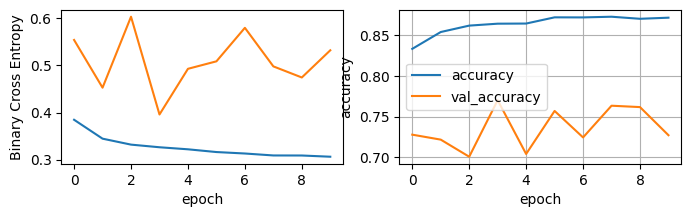

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8757 - loss: 0.3007
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 64


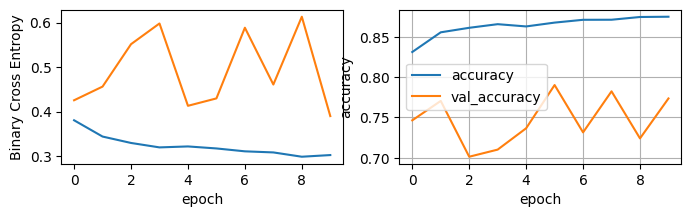

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8851 - loss: 0.2878
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 128


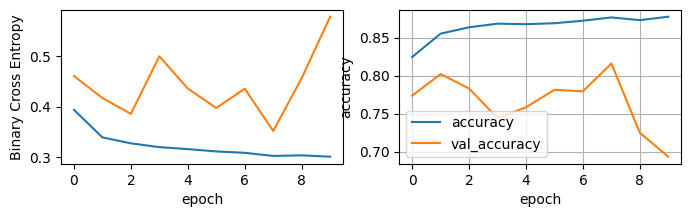

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.2949
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 32


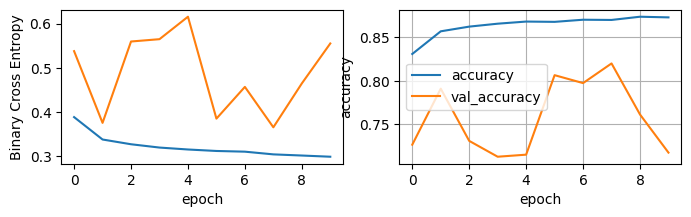

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.2865
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 64


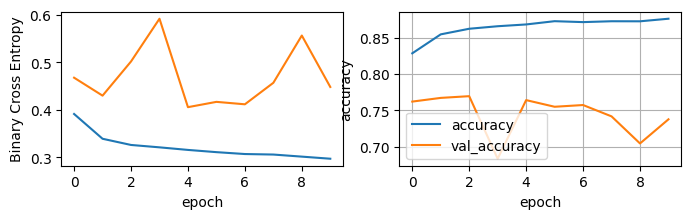

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.2850
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 128


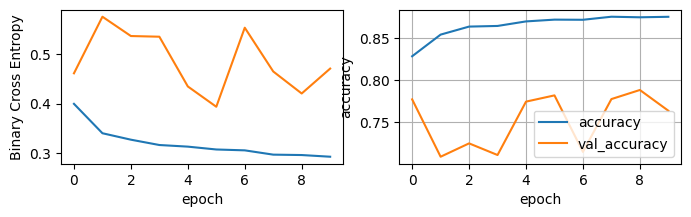

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8855 - loss: 0.2756
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 32


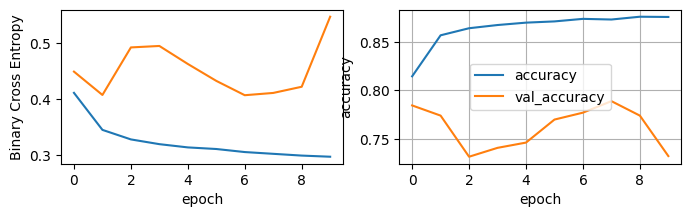

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.2841
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 64


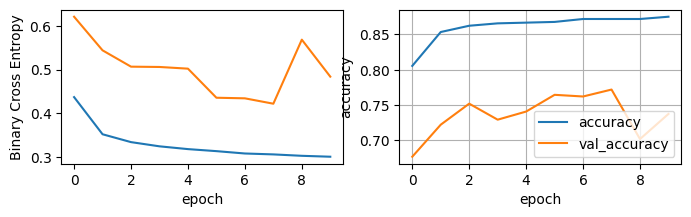

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8818 - loss: 0.2850
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 128


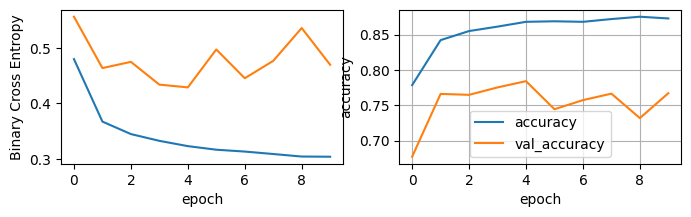

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.2921
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 32


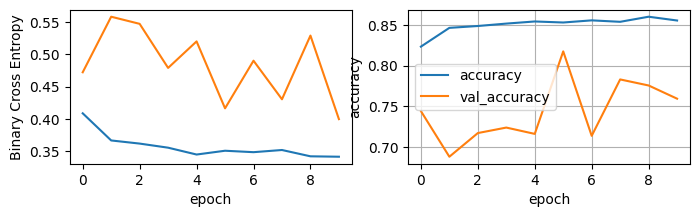

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8742 - loss: 0.3172
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 64


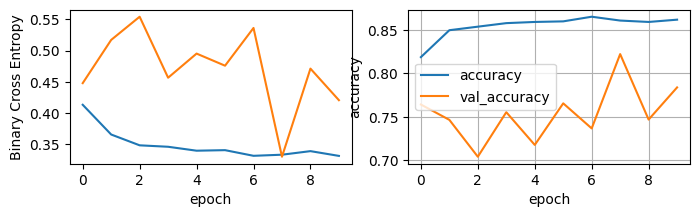

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8702 - loss: 0.3059
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 128


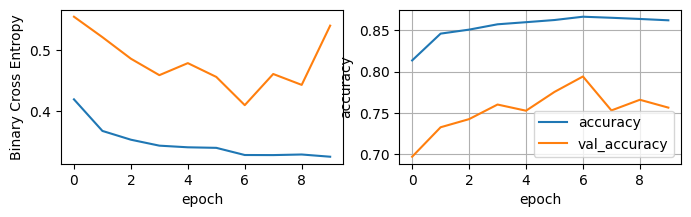

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8820 - loss: 0.2955
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 32


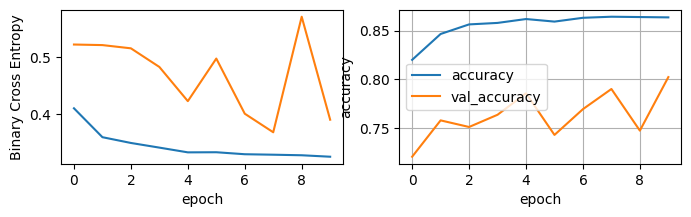

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.3036
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 64


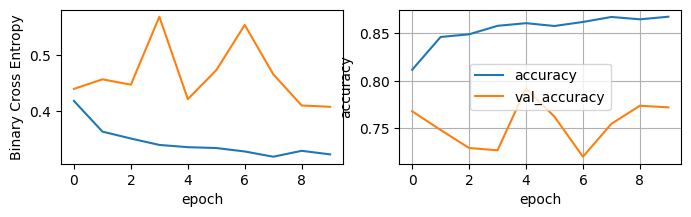

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8812 - loss: 0.2950
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 128


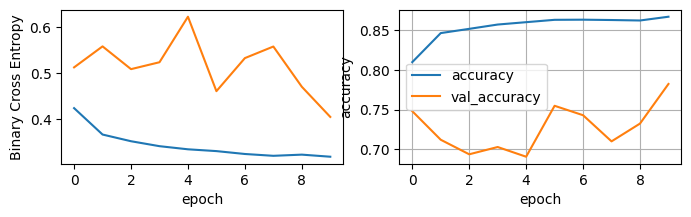

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.3010
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 32


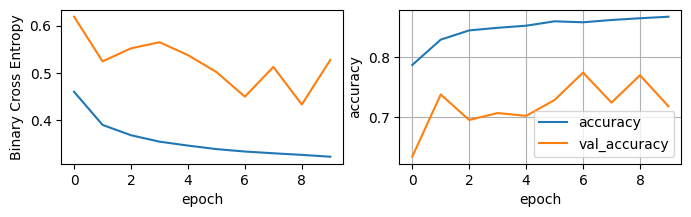

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8777 - loss: 0.2982
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 64


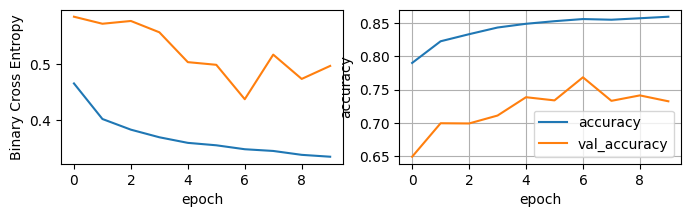

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.3011
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 128


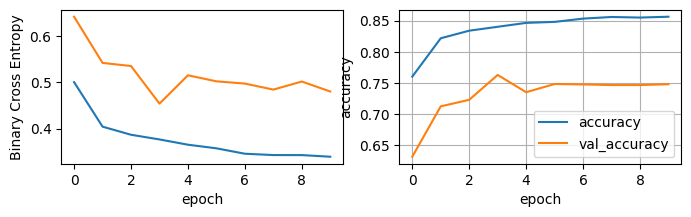

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8738 - loss: 0.3040


In [26]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 10
for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f'num_nodes = {num_nodes}, dropout_prob = {dropout_prob}, lr = {lr}, batch_size = {batch_size}')
        model, history = train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)
        val_loss, val_accuracy = model.evaluate(x_valid, y_valid)
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

0.27556082606315613
<Sequential name=sequential_41, built=True>


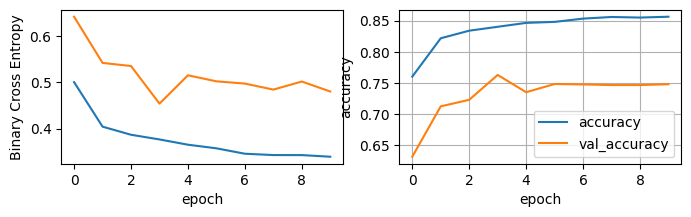

In [30]:
print(least_val_loss)
print(least_loss_model)
plot_history(history)


In [28]:
y_pred = least_loss_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)
print(y_pred)

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[1 1 1 ... 1 1 0]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      4037
           1       0.88      0.95      0.92      7375

    accuracy                           0.89     11412
   macro avg       0.89      0.86      0.87     11412
weighted avg       0.89      0.89      0.88     11412



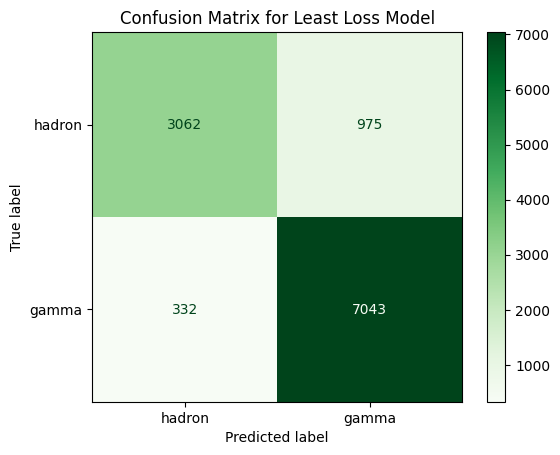

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['hadron', 'gamma'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Least Loss Model')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


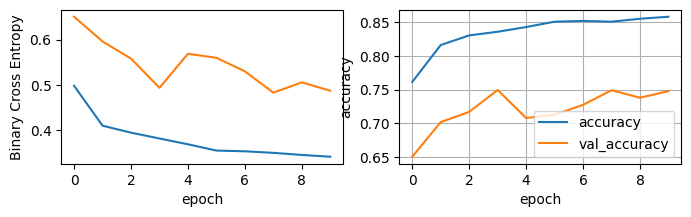

In [39]:
# Re-train the least_loss_model with its specific hyperparameters to get its history
# Best hyperparameters identified from the previous search were:
# num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 128, epochs = 10

best_num_nodes = 64
best_dropout_prob = 0.2
best_lr = 0.001
best_batch_size = 128
best_epochs = 10

# Train the model with the best parameters and capture its history
final_model, history_final_model = train_model(
    x_train, y_train, best_num_nodes, best_dropout_prob, best_lr, best_batch_size, best_epochs
)

# Plot the history of the final model
plot_history(history_final_model)